<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES16Sim004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   alpha   beta  stability_dip  stability_emergence  entropy_dip  \
0    0.2  0.002     -17.760759             0.026030   -21.350708   
1    0.2  0.005     -17.775169             0.025957   -21.371357   
2    0.2  0.008     -17.789377             0.025885   -21.391672   
3    0.2  0.011     -17.803407             0.025815   -21.411662   
4    0.2  0.014     -17.817269             0.025747   -21.431384   

   gradient_dip  curvature_energy_mean  
0    -14.170810              37.417026  
1    -14.178981              37.525154  
2    -14.187081              37.631747  
3    -14.195151              37.736658  
4    -14.203154              37.840228  


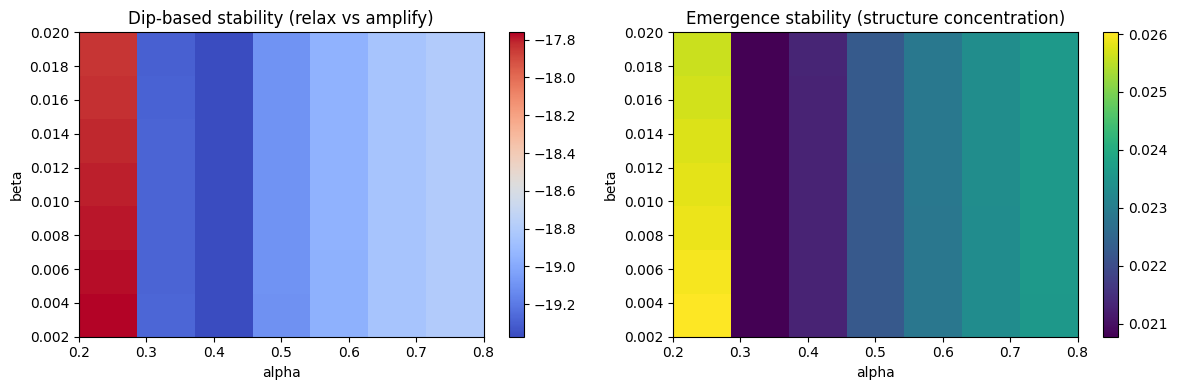

In [1]:
import numpy as np
import pandas as pd

def run_once(alpha, beta, gamma=0.0001, steps=50, L=20, seed=42):
    rng = np.random.default_rng(seed)
    s = np.clip(rng.uniform(-1.0, 1.0, (L, L, L)), -1.0, 1.0)
    s[5:10, 5:10, 5:10] += 0.5
    s[12:15, 12:15, 12:15] -= 0.5

    def laplacian_3d(a):
        return (
            np.roll(a, 1, axis=0) + np.roll(a, -1, axis=0) +
            np.roll(a, 1, axis=1) + np.roll(a, -1, axis=1) +
            np.roll(a, 1, axis=2) + np.roll(a, -1, axis=2) - 6 * a
        )

    def grad_energy(a):
        return float(np.mean(np.sqrt(
            (np.roll(a,-1,0)-a)**2 +
            (np.roll(a,-1,1)-a)**2 +
            (np.roll(a,-1,2)-a)**2
        )))

    ent0 = np.var(s)
    grad0 = grad_energy(s)

    curvature_energy_series = []

    for t in range(steps):
        lap = laplacian_3d(s)
        global_entropy = np.mean(s) * 0.995
        s += alpha * lap - beta * s - gamma * global_entropy
        s = np.clip(s, -5.0, 5.0)
        curvature_energy_series.append(float(np.mean(np.abs(lap))))

    entT = np.var(s)
    gradT = grad_energy(s)

    stability_dip = 0.5 * ((ent0 - entT) + (grad0 - gradT))
    stability_emergence = 1.0 / (1.0 + np.mean(curvature_energy_series))

    return {
        'alpha': alpha,
        'beta': beta,
        'stability_dip': stability_dip,
        'stability_emergence': stability_emergence,
        'entropy_dip': (ent0 - entT),
        'gradient_dip': (grad0 - gradT),
        'curvature_energy_mean': np.mean(curvature_energy_series)
    }

# Define sweep grid
alpha_vals = np.linspace(0.2, 0.8, 7)   # adjust range/resolution as desired
beta_vals  = np.linspace(0.002, 0.02, 7)

rows = []
for a in alpha_vals:
    for b in beta_vals:
        rows.append(run_once(alpha=a, beta=b))

sweep_df = pd.DataFrame(rows)
print(sweep_df.head())
import matplotlib.pyplot as plt

# Pivot to grids for heatmap
pivot_dip = sweep_df.pivot(index='beta', columns='alpha', values='stability_dip')
pivot_emg = sweep_df.pivot(index='beta', columns='alpha', values='stability_emergence')

fig, axes = plt.subplots(1, 2, figsize=(12,4))

im0 = axes[0].imshow(pivot_dip.values, origin='lower',
                     extent=[pivot_dip.columns.min(), pivot_dip.columns.max(),
                             pivot_dip.index.min(), pivot_dip.index.max()],
                     aspect='auto', cmap='coolwarm')
axes[0].set_title('Dip-based stability (relax vs amplify)')
axes[0].set_xlabel('alpha'); axes[0].set_ylabel('beta')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pivot_emg.values, origin='lower',
                     extent=[pivot_emg.columns.min(), pivot_emg.columns.max(),
                             pivot_emg.index.min(), pivot_emg.index.max()],
                     aspect='auto', cmap='viridis')
axes[1].set_title('Emergence stability (structure concentration)')
axes[1].set_xlabel('alpha'); axes[1].set_ylabel('beta')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


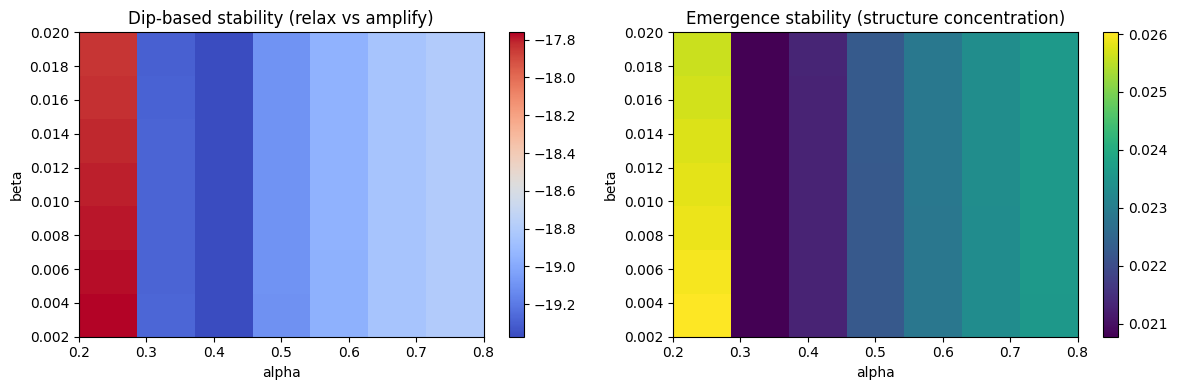

In [2]:
import matplotlib.pyplot as plt

# Pivot to grids for heatmap
pivot_dip = sweep_df.pivot(index='beta', columns='alpha', values='stability_dip')
pivot_emg = sweep_df.pivot(index='beta', columns='alpha', values='stability_emergence')

fig, axes = plt.subplots(1, 2, figsize=(12,4))

im0 = axes[0].imshow(pivot_dip.values, origin='lower',
                     extent=[pivot_dip.columns.min(), pivot_dip.columns.max(),
                             pivot_dip.index.min(), pivot_dip.index.max()],
                     aspect='auto', cmap='coolwarm')
axes[0].set_title('Dip-based stability (relax vs amplify)')
axes[0].set_xlabel('alpha'); axes[0].set_ylabel('beta')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pivot_emg.values, origin='lower',
                     extent=[pivot_emg.columns.min(), pivot_emg.columns.max(),
                             pivot_emg.index.min(), pivot_emg.index.max()],
                     aspect='auto', cmap='viridis')
axes[1].set_title('Emergence stability (structure concentration)')
axes[1].set_xlabel('alpha'); axes[1].set_ylabel('beta')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()
